# EcoWatt AI

## Exploratory Data Analysis (EDA)

### Step 1: Load the Dataset

In [2]:
import pandas as pd

df = pd.read_csv(
    "../dataset/household_power_consumption.txt",
    sep=";",
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
import sys
print(sys.executable)

d:\EcoWatt-AI\venv\Scripts\python.exe


In [4]:
import sys
print(sys.executable)

d:\EcoWatt-AI\venv\Scripts\python.exe


In [5]:
import pandas as pd

df = pd.read_csv(
    "../dataset/household_power_consumption.txt",
    sep=";",
    na_values=["?"],
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 176.0 MB


In [7]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [8]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


## Step 3 : Create Datetime Column

In [9]:
# Combine Date and Time into one Datetime column

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   Datetime               datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 191.9 MB


In [11]:
df[["Date", "Time", "Datetime"]].head()

,Date,Time,Datetime
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00


In [12]:
df[df.isnull().any(axis=1)].head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
6839,21/12/2006,11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:23:00
6840,21/12/2006,11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:24:00
19724,30/12/2006,10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:08:00
19725,30/12/2006,10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:09:00
41832,14/1/2007,18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-01-14 18:36:00


In [13]:
df[df.isnull().any(axis=1)].shape

(25979, 10)

## Step 3: Remove Missing Values

In [14]:
# Remove rows containing missing values

df = df.dropna()

# Reset the index after removing rows
df.reset_index(drop=True, inplace=True)

# Check the new shape
print(df.shape)

# Verify that no missing values remain
print(df.isnull().sum())

(2049280, 10)
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Datetime                 0
dtype: int64


## Step 4: Set Datetime as Index

In [15]:
# Set Datetime as the index
df.set_index("Datetime", inplace=True)

# Remove Date and Time columns
df.drop(columns=["Date", "Time"], inplace=True)

# Display first five rows
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Step 5: Convert Minute-Level Data into Daily Data

In [16]:
# Aggregate the data day-wise

daily_df = df.resample("D").agg({
    "Global_active_power": "sum",
    "Global_reactive_power": "sum",
    "Voltage": "mean",
    "Global_intensity": "mean",
    "Sub_metering_1": "sum",
    "Sub_metering_2": "sum",
    "Sub_metering_3": "sum"
})

# Display the first 5 rows
daily_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,1209.176,34.922,236.243763,13.082828,0.0,546.0,4926.0
2006-12-17,3390.460,226.006,240.087028,9.999028,2033.0,4187.0,13341.0
2006-12-18,2203.826,161.792,241.231694,6.421667,1063.0,2621.0,14018.0
2006-12-19,1666.194,150.942,241.999313,4.926389,839.0,7602.0,6197.0
2006-12-20,2225.748,160.998,242.308062,6.467361,0.0,2648.0,14063.0


In [17]:
print("Shape of Daily Dataset:", daily_df.shape)

Shape of Daily Dataset: (1442, 7)


## Step 6: Convert Daily Power to Daily Energy (kWh)

In [18]:
# Convert daily summed power into daily energy (kWh)

daily_df["Daily_Energy_kWh"] = daily_df["Global_active_power"] / 60

# Display the first five rows
daily_df[["Global_active_power", "Daily_Energy_kWh"]].head()

,Global_active_power,Daily_Energy_kWh
Datetime,,
2006-12-16,1209.176,20.152933
2006-12-17,3390.460,56.507667
2006-12-18,2203.826,36.730433
2006-12-19,1666.194,27.769900
2006-12-20,2225.748,37.095800


In [19]:
daily_df[["Global_active_power", "Daily_Energy_kWh"]].head()

,Global_active_power,Daily_Energy_kWh
Datetime,,
2006-12-16,1209.176,20.152933
2006-12-17,3390.460,56.507667
2006-12-18,2203.826,36.730433
2006-12-19,1666.194,27.769900
2006-12-20,2225.748,37.095800


## Step 6: Visualize Daily Energy Consumption

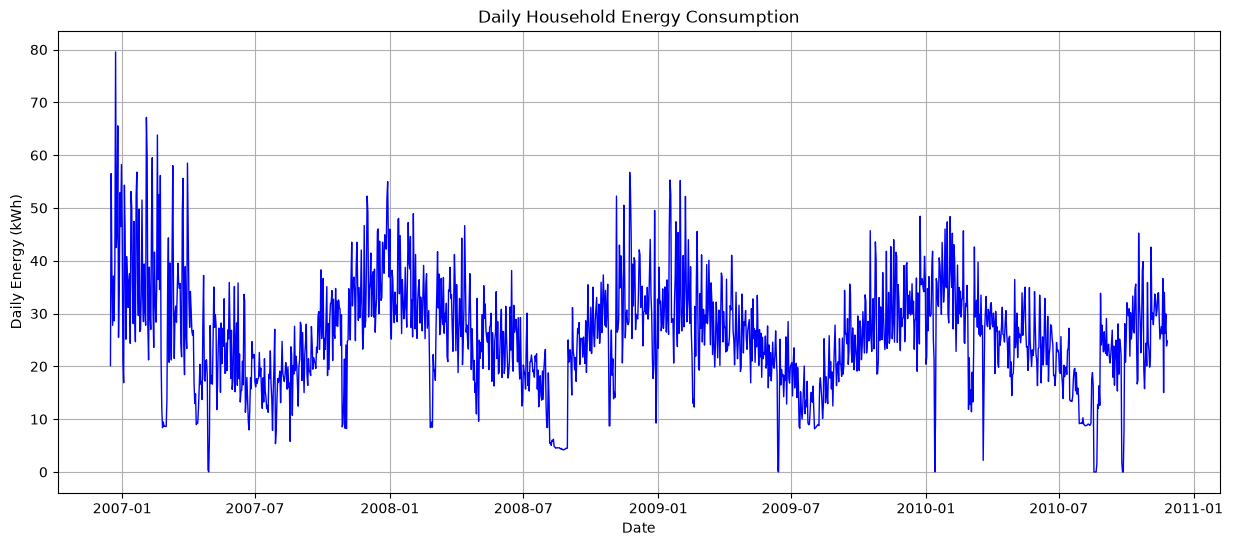

In [20]:
import matplotlib.pyplot as plt

# Plot Daily Energy Consumption
plt.figure(figsize=(15,6))

plt.plot(
    daily_df.index,
    daily_df["Daily_Energy_kWh"],
    color="blue",
    linewidth=1
)

plt.title("Daily Household Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Daily Energy (kWh)")
plt.grid(True)

plt.show()

# Step 7 : Analyze Daily Energy Consumption

In [21]:
# Statistical summary of Daily Energy Consumption

daily_df["Daily_Energy_kWh"].describe()

count    1442.000000
mean       25.855581
std        10.288285
min         0.000000
25%        19.353308
50%        25.579633
75%        31.497658
max        79.556433
Name: Daily_Energy_kWh, dtype: float64

## Step 8 : Detect Outliers using Box Plot

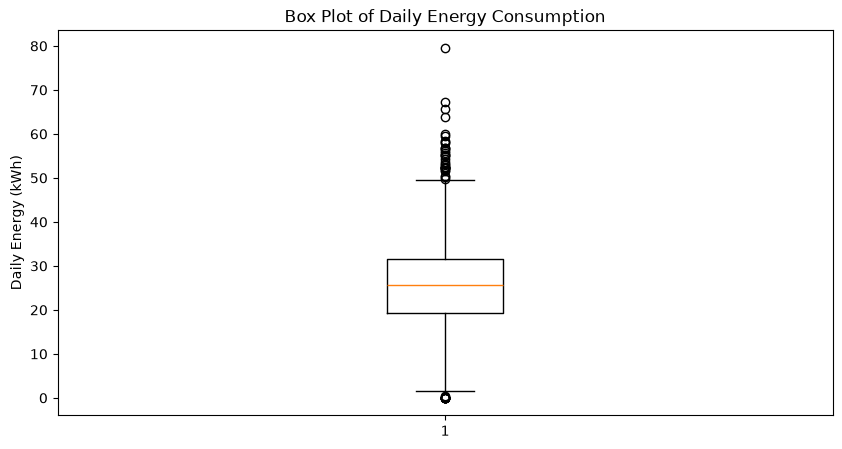

In [22]:
plt.figure(figsize=(10,5))

plt.boxplot(daily_df["Daily_Energy_kWh"])

plt.title("Box Plot of Daily Energy Consumption")

plt.ylabel("Daily Energy (kWh)")

plt.show()

# Step 9 : Prepare Dataset for Prophet

In [23]:
# Create a new DataFrame for Prophet

prophet_df = daily_df.reset_index()[["Datetime", "Daily_Energy_kWh"]]

# Rename columns as required by Prophet
prophet_df.columns = ["ds", "y"]

# Display first five rows
prophet_df.head()

,ds,y
0,2006-12-16,20.152933
1,2006-12-17,56.507667
2,2006-12-18,36.730433
3,2006-12-19,27.769900
4,2006-12-20,37.095800


In [24]:
print(prophet_df.shape)
print(prophet_df.info())

(1442, 2)
<class 'pandas.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1442 non-null   datetime64[us]
 1   y       1442 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 22.7 KB
None


# Step 10 : Train Facebook Prophet Model

In [25]:
from prophet import Prophet

# Create the Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train the model
model.fit(prophet_df)

print("Model Training Completed Successfully!")

11:32:28 - cmdstanpy - INFO - Chain [1] start processing
11:32:28 - cmdstanpy - INFO - Chain [1] done processing


Model Training Completed Successfully!


# Step 11 : Predict Next 7 Days

In [26]:
# Create future dates (next 7 days)

future = model.make_future_dataframe(
    periods=7,
    freq="D"
)

future.tail(10)

,ds
1439,2010-11-24
1440,2010-11-25
1441,2010-11-26
1442,2010-11-27
1443,2010-11-28
1444,2010-11-29
1445,2010-11-30
1446,2010-12-01
1447,2010-12-02
1448,2010-12-03


In [27]:
# Predict future values

forecast = model.predict(future)

forecast.tail(10)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1439,2010-11-24,25.218605,24.457154,43.174613,25.218605,25.218605,8.293551,8.293551,8.293551,-0.133830,-0.133830,-0.133830,8.427382,8.427382,8.427382,0.0,0.0,0.0,33.512156
1440,2010-11-25,25.217905,21.483625,39.887959,25.217905,25.217905,5.813593,5.813593,5.813593,-2.566311,-2.566311,-2.566311,8.379904,8.379904,8.379904,0.0,0.0,0.0,31.031498
1441,2010-11-26,25.217204,23.598581,41.505584,25.217204,25.217204,7.341950,7.341950,7.341950,-0.946975,-0.946975,-0.946975,8.288925,8.288925,8.288925,0.0,0.0,0.0,32.559155
1442,2010-11-27,25.216504,27.830456,46.527951,25.216504,25.216504,11.473724,11.473724,11.473724,3.311987,3.311987,3.311987,8.161736,8.161736,8.161736,0.0,0.0,0.0,36.690228
1443,2010-11-28,25.215804,26.670988,45.181483,25.215804,25.215804,10.780304,10.780304,10.780304,2.773860,2.773860,2.773860,8.006444,8.006444,8.006444,0.0,0.0,0.0,35.996108
1444,2010-11-29,25.215104,21.529100,40.528588,25.215104,25.215104,5.739419,5.739419,5.739419,-2.092311,-2.092311,-2.092311,7.831730,7.831730,7.831730,0.0,0.0,0.0,30.954523
1445,2010-11-30,25.214404,23.043696,41.985131,25.214404,25.214404,7.300171,7.300171,7.300171,-0.346420,-0.346420,-0.346420,7.646591,7.646591,7.646591,0.0,0.0,0.0,32.514575
1446,2010-12-01,25.213704,23.708775,41.923912,25.213704,25.213704,7.326251,7.326251,7.326251,-0.133830,-0.133830,-0.133830,7.460081,7.460081,7.460081,0.0,0.0,0.0,32.539955
1447,2010-12-02,25.213004,20.622125,39.510346,25.213004,25.213004,4.714735,4.714735,4.714735,-2.566311,-2.566311,-2.566311,7.281047,7.281047,7.281047,0.0,0.0,0.0,29.927739
1448,2010-12-03,25.212304,22.171254,40.852591,25.212304,25.212304,6.170896,6.170896,6.170896,-0.946975,-0.946975,-0.946975,7.117871,7.117871,7.117871,0.0,0.0,0.0,31.383200


In [28]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7)

,ds,yhat,yhat_lower,yhat_upper
1442,2010-11-27,36.690228,27.830456,46.527951
1443,2010-11-28,35.996108,26.670988,45.181483
1444,2010-11-29,30.954523,21.529100,40.528588
1445,2010-11-30,32.514575,23.043696,41.985131
1446,2010-12-01,32.539955,23.708775,41.923912
1447,2010-12-02,29.927739,20.622125,39.510346
1448,2010-12-03,31.383200,22.171254,40.852591


# Step 12 : Visualize Forecast

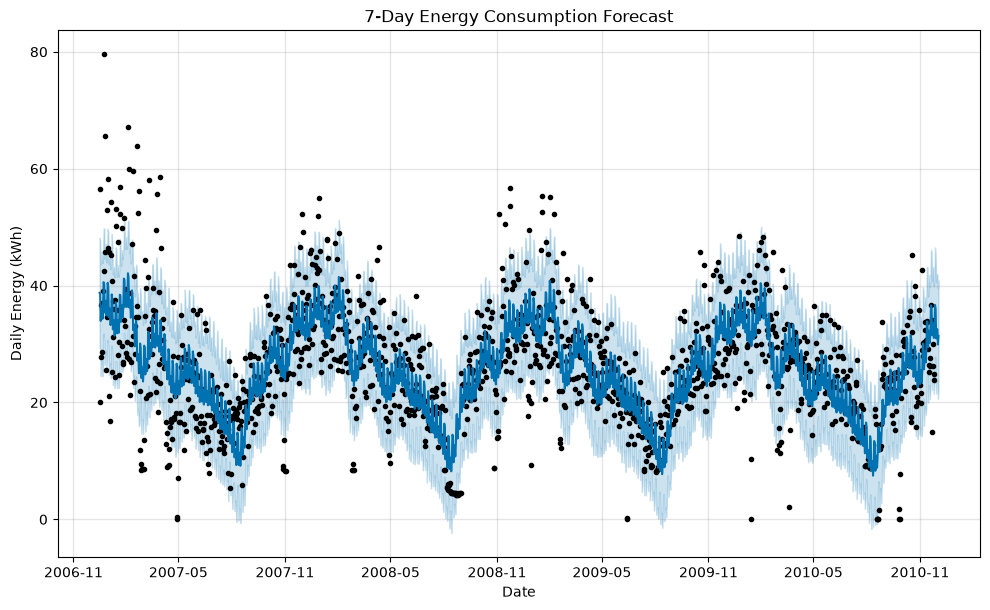

In [29]:
# Plot the forecast

fig1 = model.plot(forecast)

plt.title("7-Day Energy Consumption Forecast")

plt.xlabel("Date")

plt.ylabel("Daily Energy (kWh)")

plt.grid(True)

plt.show()

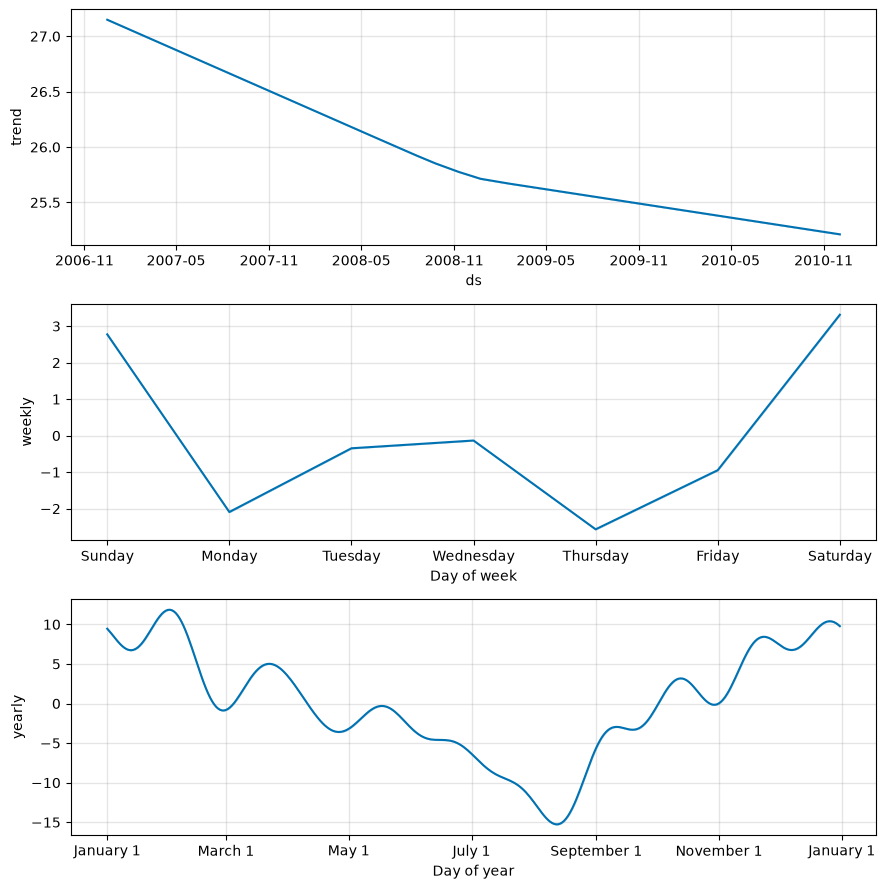

In [30]:
# Plot forecast components

fig2 = model.plot_components(forecast)

plt.show()

# Step 13 : Evaluate Model Performance

In [31]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Merge actual and predicted values
evaluation_df = prophet_df.merge(
    forecast[["ds", "yhat"]],
    on="ds"
)

# Calculate MAE
mae = mean_absolute_error(
    evaluation_df["y"],
    evaluation_df["yhat"]
)

# Calculate RMSE
rmse = np.sqrt(
    mean_squared_error(
        evaluation_df["y"],
        evaluation_df["yhat"]
    )
)

print(f"Mean Absolute Error (MAE): {mae:.2f} kWh")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} kWh")

Mean Absolute Error (MAE): 5.41 kWh
Root Mean Squared Error (RMSE): 7.36 kWh


# Step 14 : Save the Trained Prophet Model

In [32]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(model, "../models/prophet_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [33]:
import os

print(os.listdir("../models"))

['prophet_model.pkl']
